# Pandas Indicator Tester (One-by-One)

Pure **pandas/numpy** technical indicators — no TA-Lib required.

Run setup cells once, then run any indicator cell below.

```bash
pip install -e ".[notebook]"
jupyter lab notebooks/pandas_indicator_tester.ipynb
```


In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from indicator_testing.data_loader import describe_ohlc, load_ohlc
from indicator_testing.pandas_indicators import PandasIndicatorRegistry
from indicator_testing.pandas_runner import run_pandas_indicator

print(f"Project root: {PROJECT_ROOT}")


Project root: d:\Projects\Indicator Testing


## Configuration


In [2]:
CSV_PATH = PROJECT_ROOT / "questdb-query-1781940224994.csv"
RESAMPLE = "none"   # "none" | "daily" | "monthly" | "weekly"
SYMBOL = None


In [3]:
resample_arg = None if RESAMPLE == "none" else RESAMPLE
df = load_ohlc(CSV_PATH, resample=resample_arg, symbol=SYMBOL, warn_short=False)
registry = PandasIndicatorRegistry()
info = describe_ohlc(df)

print(f"Loaded {info['bars']} bars | {info['inferred_frequency']}")
print(f"Pandas indicators: {len(registry.all_names())}")
df.tail(3)


Loaded 19503 bars | intraday (minute/sub-minute)
Pandas indicators: 37


C:\Users\mohxm\AppData\Local\Temp\ipykernel_33976\241344708.py:2: UserWarning: Dropping 16500 duplicate timestamp(s), keeping last occurrence.
  df = load_ohlc(CSV_PATH, resample=resample_arg, symbol=SYMBOL, warn_short=False)
C:\Users\mohxm\AppData\Local\Temp\ipykernel_33976\241344708.py:2: UserWarning: Data looks intraday (~60s bars). Use --resample monthly or --resample daily for aggregated testing.
  df = load_ohlc(CSV_PATH, resample=resample_arg, symbol=SYMBOL, warn_short=False)


,open,high,low,close,volume
date,,,,,
2026-06-19 15:27:00+00:00,24027.5,24036.85,24023.10,24035.6,5888123
2026-06-19 15:28:00+00:00,24033.8,24043.15,24031.15,24042.1,3461609
2026-06-19 15:29:00+00:00,24037.4,24047.20,24034.90,24042.7,2148843


## Helpers


In [4]:
def show_validation(result):
    meta = registry.get(result.name)
    print(f"{'='*60}")
    print(f"{result.name}  |  {result.group}  (pandas)")
    print(f"Status: {result.status}  |  Warmup: {result.warmup_bars}")
    print(f"Outputs: {meta.output_names}  |  Params: {result.params_used}")
    if result.message and result.status != "success":
        print(f"Message: {result.message}")
    if result.validation:
        tag = "PASS" if result.validation.passed else "FAIL"
        print(f"Validation: {tag}")
        for c in result.validation.checks:
            mark = "OK" if c.passed else "X"
            print(f"  [{mark}] {c.name}: {c.message}")
    print(f"{'='*60}")


def result_to_frame(result, n_tail=15):
    if result.status != "success" or not result.outputs:
        return pd.DataFrame()
    out = pd.DataFrame({"close": df["close"]})
    for k, arr in result.outputs.items():
        out[k] = arr
    out.index = df.index
    return out.tail(n_tail)


def plot_pandas(result):
    if result.status != "success" or not result.outputs:
        print("Nothing to plot.")
        return
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(df.index, df["close"], label="Close", color="black", lw=1)
    axes[0].set_ylabel("Price")
    axes[0].legend(loc="upper left")
    for key, arr in result.outputs.items():
        axes[1].plot(df.index, arr, label=key, lw=1)
    axes[1].set_ylabel(result.name)
    axes[1].legend(loc="upper left")
    fig.suptitle(f"{result.name} (pandas) — {result.params_used}")
    fig.tight_layout()
    plt.show()


def test_pandas_indicator(name, params=None):
    result = run_pandas_indicator(name, df, registry, params=params)
    show_validation(result)
    display(result_to_frame(result))
    plot_pandas(result)
    return result


## Table of contents

- [Overlap Studies](#overlap-studies)
- [Momentum Indicators](#momentum-indicators)
- [Volatility Indicators](#volatility-indicators)
- [Volume Indicators](#volume-indicators)
- [Price Transform](#price-transform)
- [Statistic Functions](#statistic-functions)


<a id="overlap-studies"></a>
## Overlap Studies (7)


### SMA
Outputs: `['sma']` · Defaults: `{'length': 20}`


SMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 19
Outputs: ['sma']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,sma
date,,
2026-06-19 15:15:00+00:00,24016.85,23992.2750
2026-06-19 15:16:00+00:00,24018.85,23997.7500
2026-06-19 15:17:00+00:00,24027.60,24003.5900
2026-06-19 15:18:00+00:00,24025.75,24009.6375
2026-06-19 15:19:00+00:00,24028.00,24015.5100
2026-06-19 15:20:00+00:00,24031.15,24019.3650
2026-06-19 15:21:00+00:00,24030.90,24022.5650
2026-06-19 15:22:00+00:00,24027.20,24024.2400
2026-06-19 15:23:00+00:00,24031.65,24025.9100


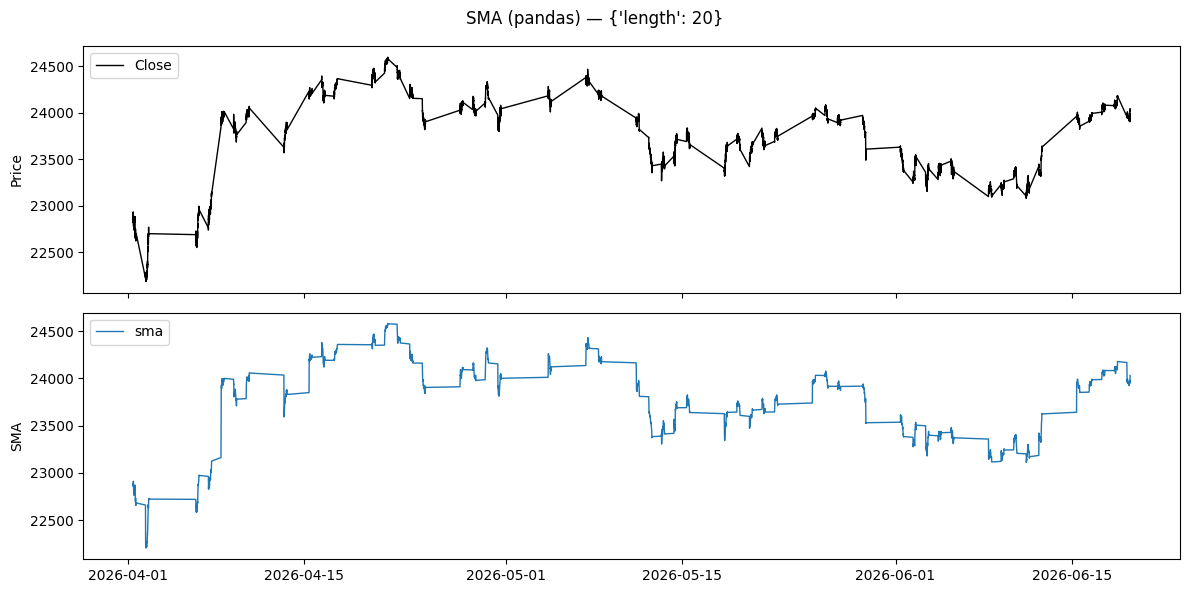

IndicatorResult(name='SMA', group='Overlap Studies', params_used={'length': 20}, outputs={'sma': array([       nan,        nan,        nan, ..., 24028.9025, 24029.845 ,
       24030.85  ])}, warmup_bars=19, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [5]:
test_pandas_indicator("SMA")


### EMA
Outputs: `['ema']` · Defaults: `{'length': 20}`


EMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 0
Outputs: ['ema']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,ema
date,,
2026-06-19 15:15:00+00:00,24016.85,24004.440952
2026-06-19 15:16:00+00:00,24018.85,24005.813243
2026-06-19 15:17:00+00:00,24027.60,24007.888172
2026-06-19 15:18:00+00:00,24025.75,24009.589298
2026-06-19 15:19:00+00:00,24028.00,24011.342698
2026-06-19 15:20:00+00:00,24031.15,24013.229108
2026-06-19 15:21:00+00:00,24030.90,24014.912050
2026-06-19 15:22:00+00:00,24027.20,24016.082331
2026-06-19 15:23:00+00:00,24031.65,24017.564966


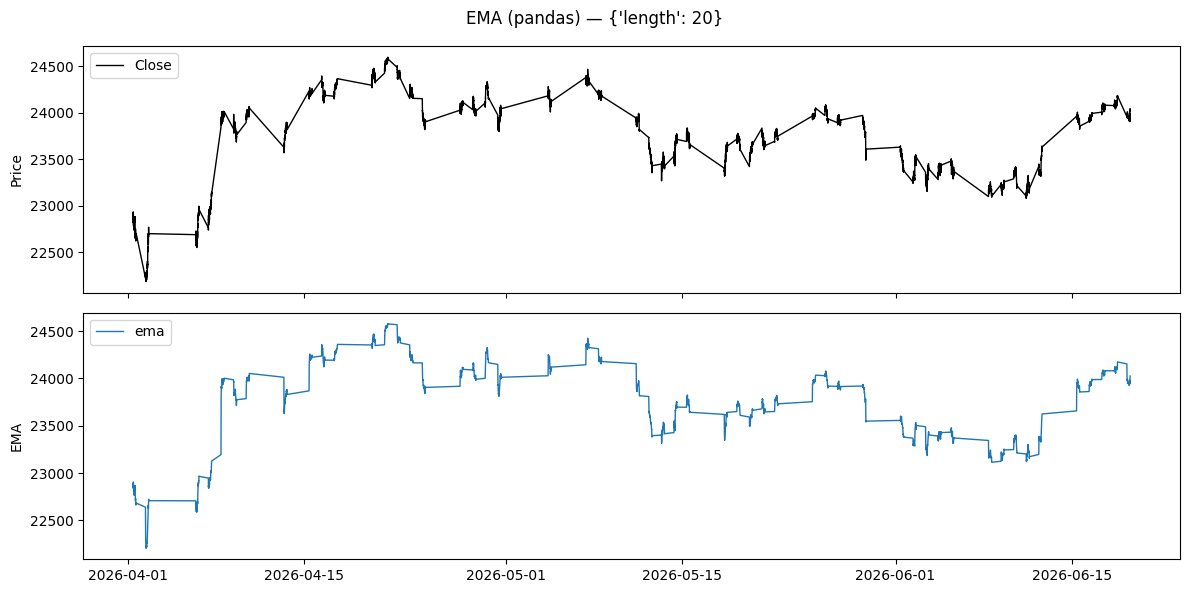

IndicatorResult(name='EMA', group='Overlap Studies', params_used={'length': 20}, outputs={'ema': array([22843.45      , 22841.60714286, 22844.2207483 , ...,
       24022.16247383, 24024.06128584, 24025.83640148])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [6]:
test_pandas_indicator("EMA")


### WMA
Outputs: `['wma']` · Defaults: `{'length': 20}`


WMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 19
Outputs: ['wma']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,wma
date,,
2026-06-19 15:15:00+00:00,24016.85,24014.868810
2026-06-19 15:16:00+00:00,24018.85,24017.399762
2026-06-19 15:17:00+00:00,24027.60,24020.242619
2026-06-19 15:18:00+00:00,24025.75,24022.353095
2026-06-19 15:19:00+00:00,24028.00,24024.101905
2026-06-19 15:20:00+00:00,24031.15,24025.591429
2026-06-19 15:21:00+00:00,24030.90,24026.690000
2026-06-19 15:22:00+00:00,24027.20,24027.131429
2026-06-19 15:23:00+00:00,24031.65,24027.837143


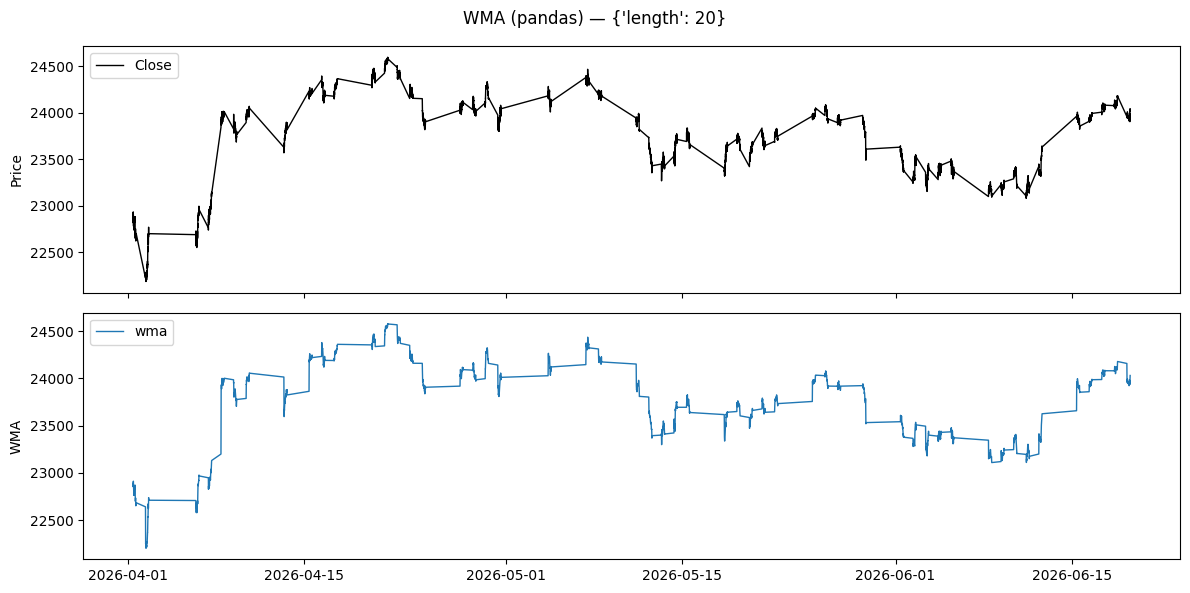

IndicatorResult(name='WMA', group='Overlap Studies', params_used={'length': 20}, outputs={'wma': array([           nan,            nan,            nan, ...,
       24029.40071429, 24030.65761905, 24031.88190476])}, warmup_bars=19, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [7]:
test_pandas_indicator("WMA")


### DEMA
Outputs: `['dema']` · Defaults: `{'length': 20}`


DEMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 0
Outputs: ['dema']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,dema
date,,
2026-06-19 15:15:00+00:00,24016.85,24028.981681
2026-06-19 15:16:00+00:00,24018.85,24029.258355
2026-06-19 15:17:00+00:00,24027.60,24030.977734
2026-06-19 15:18:00+00:00,24025.75,24032.018969
2026-06-19 15:19:00+00:00,24028.00,24033.222619
2026-06-19 15:20:00+00:00,24031.15,24034.731979
2026-06-19 15:21:00+00:00,24030.90,24035.889690
2026-06-19 15:22:00+00:00,24027.20,24036.120926
2026-06-19 15:23:00+00:00,24031.65,24037.036556


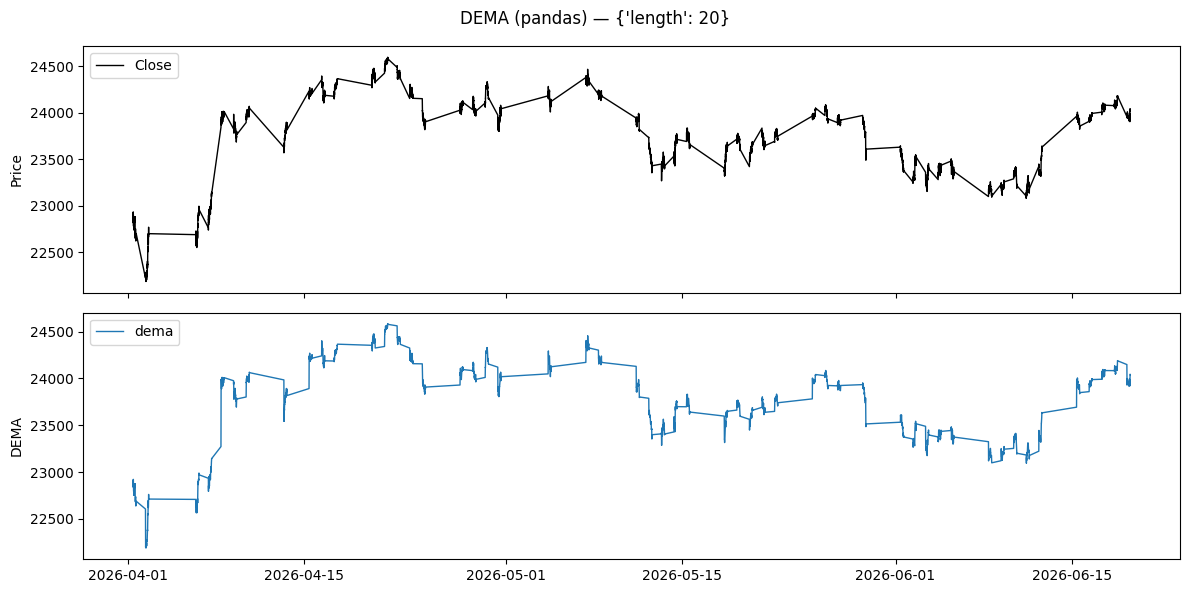

IndicatorResult(name='DEMA', group='Overlap Studies', params_used={'length': 20}, outputs={'dema': array([22843.45      , 22839.93979592, 22845.07688695, ...,
       24038.79280028, 24040.82574445, 24042.61030198])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [8]:
test_pandas_indicator("DEMA")


### TEMA
Outputs: `['tema']` · Defaults: `{'length': 20}`


TEMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 0
Outputs: ['tema']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,tema
date,,
2026-06-19 15:15:00+00:00,24016.85,24041.743906
2026-06-19 15:16:00+00:00,24018.85,24039.813858
2026-06-19 15:17:00+00:00,24027.60,24040.206262
2026-06-19 15:18:00+00:00,24025.75,24039.771545
2026-06-19 15:19:00+00:00,24028.00,24039.739463
2026-06-19 15:20:00+00:00,24031.15,24040.287029
2026-06-19 15:21:00+00:00,24030.90,24040.440480
2026-06-19 15:22:00+00:00,24027.20,24039.388695
2026-06-19 15:23:00+00:00,24031.65,24039.480103


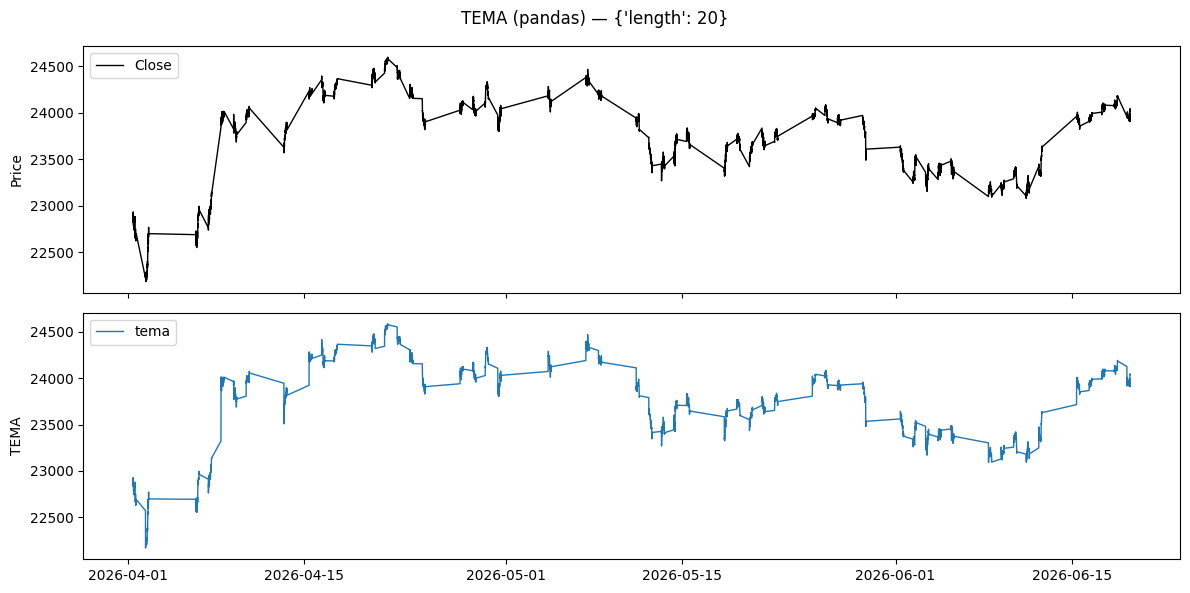

IndicatorResult(name='TEMA', group='Overlap Studies', params_used={'length': 20}, outputs={'tema': array([22843.45      , 22838.43124393, 22845.9951602 , ...,
       24038.21800614, 24040.42705029, 24042.25812136])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [9]:
test_pandas_indicator("TEMA")


### HMA
Outputs: `['hma']` · Defaults: `{'length': 20}`


HMA  |  Overlap Studies  (pandas)
Status: success  |  Warmup: 22
Outputs: ['hma']  |  Params: {'length': 20}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,hma
date,,
2026-06-19 15:15:00+00:00,24016.85,24046.989398
2026-06-19 15:16:00+00:00,24018.85,24041.879455
2026-06-19 15:17:00+00:00,24027.60,24037.387275
2026-06-19 15:18:00+00:00,24025.75,24033.632597
2026-06-19 15:19:00+00:00,24028.00,24030.965537
2026-06-19 15:20:00+00:00,24031.15,24029.377613
2026-06-19 15:21:00+00:00,24030.90,24028.515245
2026-06-19 15:22:00+00:00,24027.20,24027.930861
2026-06-19 15:23:00+00:00,24031.65,24028.098935


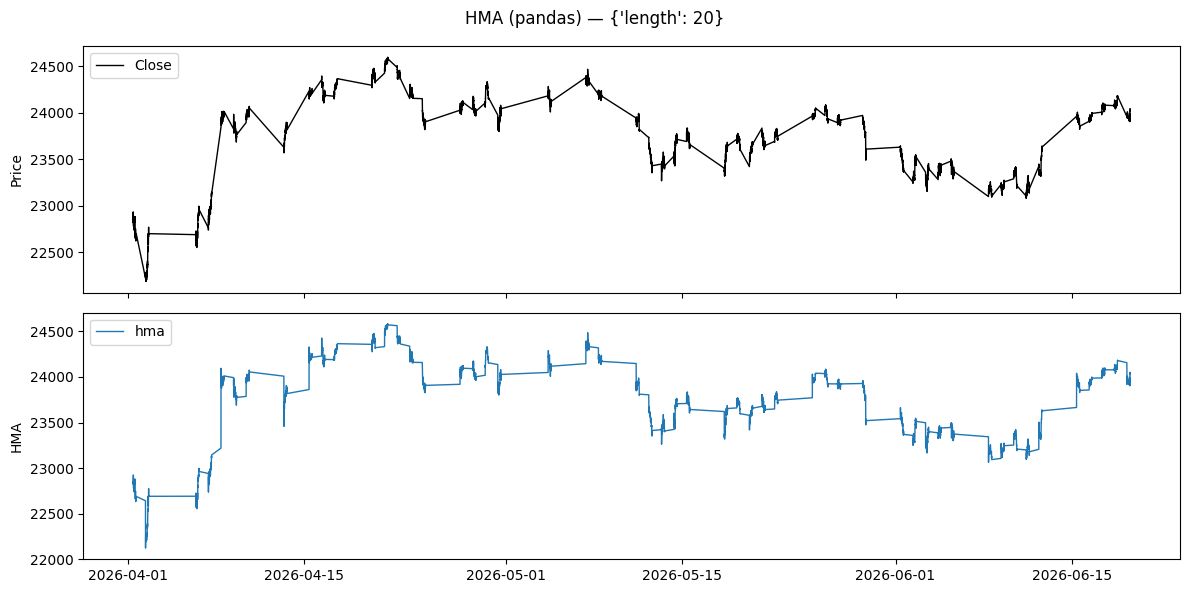

IndicatorResult(name='HMA', group='Overlap Studies', params_used={'length': 20}, outputs={'hma': array([           nan,            nan,            nan, ...,
       24031.32743723, 24033.04829004, 24035.39429004])}, warmup_bars=22, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [10]:
test_pandas_indicator("HMA")


### VWMA
Outputs: `['vwma']` · Defaults: `{'length': 20}` · requires volume


In [ ]:
test_pandas_indicator("VWMA")


<a id="momentum-indicators"></a>
## Momentum Indicators (12)


### RSI
Outputs: `['rsi']` · Defaults: `{'length': 14}`


In [ ]:
test_pandas_indicator("RSI")


### MACD
Outputs: `['macd', 'macdsignal', 'macdhist']` · Defaults: `{'fast': 12, 'slow': 26, 'signal': 9}`


In [ ]:
test_pandas_indicator("MACD")


### ROC
Outputs: `['roc']` · Defaults: `{'length': 10}`


In [ ]:
test_pandas_indicator("ROC")


### MOM
Outputs: `['mom']` · Defaults: `{'length': 10}`


In [ ]:
test_pandas_indicator("MOM")


### STOCH
Outputs: `['slowk', 'slowd']` · Defaults: `{'k': 14, 'd': 3, 'smooth_k': 3}`


In [ ]:
test_pandas_indicator("STOCH")


### STOCHRSI
Outputs: `['stochrsi_k', 'stochrsi_d']` · Defaults: `{'length': 14, 'k': 3, 'd': 3}`


In [ ]:
test_pandas_indicator("STOCHRSI")


### CCI
Outputs: `['cci']` · Defaults: `{'length': 20}`


In [ ]:
test_pandas_indicator("CCI")


### WILLR
Outputs: `['willr']` · Defaults: `{'length': 14}`


In [ ]:
test_pandas_indicator("WILLR")


### MFI
Outputs: `['mfi']` · Defaults: `{'length': 14}` · requires volume


In [ ]:
test_pandas_indicator("MFI")


### CMO
Outputs: `['cmo']` · Defaults: `{'length': 14}`


In [ ]:
test_pandas_indicator("CMO")


### PPO
Outputs: `['ppo']` · Defaults: `{'fast': 12, 'slow': 26}`


In [ ]:
test_pandas_indicator("PPO")


### TRIX
Outputs: `['trix']` · Defaults: `{'length': 15}`


In [ ]:
test_pandas_indicator("TRIX")


<a id="volatility-indicators"></a>
## Volatility Indicators (5)


### BBANDS
Outputs: `['upperband', 'middleband', 'lowerband']` · Defaults: `{'length': 20, 'std': 2.0}`


In [ ]:
test_pandas_indicator("BBANDS")


### ATR
Outputs: `['atr']` · Defaults: `{'length': 14}`


In [ ]:
test_pandas_indicator("ATR")


### NATR
Outputs: `['natr']` · Defaults: `{'length': 14}`


In [ ]:
test_pandas_indicator("NATR")


### TRANGE
Outputs: `['trange']` · Defaults: `{}`


In [ ]:
test_pandas_indicator("TRANGE")


### DONCHIAN
Outputs: `['donchian_upper', 'donchian_mid', 'donchian_lower']` · Defaults: `{'length': 20}`


In [ ]:
test_pandas_indicator("DONCHIAN")


<a id="volume-indicators"></a>
## Volume Indicators (5)


### OBV
Outputs: `['obv']` · Defaults: `{}` · requires volume


In [ ]:
test_pandas_indicator("OBV")


### AD
Outputs: `['ad']` · Defaults: `{}` · requires volume


In [ ]:
test_pandas_indicator("AD")


### ADOSC
Outputs: `['adosc']` · Defaults: `{'fast': 3, 'slow': 10}` · requires volume


In [ ]:
test_pandas_indicator("ADOSC")


### CMF
Outputs: `['cmf']` · Defaults: `{'length': 20}` · requires volume


In [ ]:
test_pandas_indicator("CMF")


### VWAP
Outputs: `['vwap']` · Defaults: `{}` · requires volume


In [ ]:
test_pandas_indicator("VWAP")


<a id="price-transform"></a>
## Price Transform (4)


### AVGPRICE
Outputs: `['avgprice']` · Defaults: `{}`


In [ ]:
test_pandas_indicator("AVGPRICE")


### MEDPRICE
Outputs: `['medprice']` · Defaults: `{}`


In [ ]:
test_pandas_indicator("MEDPRICE")


### TYPPRICE
Outputs: `['typprice']` · Defaults: `{}`


In [ ]:
test_pandas_indicator("TYPPRICE")


### WCLPRICE
Outputs: `['wclprice']` · Defaults: `{}`


In [ ]:
test_pandas_indicator("WCLPRICE")


<a id="statistic-functions"></a>
## Statistic Functions (4)


### STDDEV
Outputs: `['stddev']` · Defaults: `{'length': 5}`


In [ ]:
test_pandas_indicator("STDDEV")


### VAR
Outputs: `['var']` · Defaults: `{'length': 5}`


In [ ]:
test_pandas_indicator("VAR")


### ZSCORE
Outputs: `['zscore']` · Defaults: `{'length': 20}`


In [ ]:
test_pandas_indicator("ZSCORE")


### LINEARREG
Outputs: `['linearreg']` · Defaults: `{'length': 14}`


In [ ]:
test_pandas_indicator("LINEARREG")
